# Roman Urdu Hate Speech Detection — XLM-RoBERTa

**Model:** `FacebookAI/xlm-roberta-base`  
**Datasets:** RuHSold (primary) + HSRU-20 (secondary)  
**Labels:** 4-class unified — Normal · Abusive · Offensive · Hate  
**Hardware:** Google Colab Free Tier — T4 GPU

> **Before running:** Runtime → Change runtime type → T4 GPU

## 1. Install Dependencies

In [ ]:
!pip install -q --upgrade pip
!pip install -q \
    "transformers>=4.41.0" \
    "accelerate>=0.30.0" \
    "datasets>=2.19.0" \
    scikit-learn \
    seaborn matplotlib pandas \
    kaggle openpyxl emoji

# Verify nothing is broken before proceeding
import numpy, sklearn, transformers, accelerate, datasets
print('numpy       :', numpy.__version__)
print('sklearn     :', sklearn.__version__)
print('transformers:', transformers.__version__)
print('accelerate  :', accelerate.__version__)
print('datasets    :', datasets.__version__)
print()
print('✅ All good — run the rest of the notebook.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.6 MB/s eta 0:00:00
numpy       : 2.0.2
sklearn     : 1.6.1
transformers: 5.0.0
accelerate  : 1.13.0
datasets    : 4.0.0

✅ All good — run the rest of the notebook.


## 2. Verify GPU

In [ ]:
import torch

if torch.cuda.is_available():
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU — Runtime → Change runtime type → T4 GPU')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

✅ GPU: Tesla T4
   VRAM: 15.6 GB
Device: cuda


## 3. Kaggle Authentication & Download
Upload your `kaggle.json` from [kaggle.com → Settings → API → Create New Token](https://www.kaggle.com/settings)

In [ ]:
import os
from google.colab import files

uploaded = files.upload()   # upload kaggle.json here
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
print('✅ Kaggle credentials configured.')

Saving kaggle.json to kaggle.json
✅ Kaggle credentials configured.


In [ ]:
!kaggle datasets download -d ahmadkarimkhan/ruhsold-training         -p ./data/ruhsold --unzip -q
!kaggle datasets download -d drkhurramshahzad/hate-speech-roman-urdu -p ./data/hsru    --unzip -q

print('RuHSold files :'); [print(f'  {f}') for f in os.listdir('./data/ruhsold')]
print('HSRU-20 files :'); [print(f'  {f}') for f in os.listdir('./data/hsru')]

Dataset URL: https://www.kaggle.com/datasets/ahmadkarimkhan/ruhsold-training
License(s): unknown
Dataset URL: https://www.kaggle.com/datasets/drkhurramshahzad/hate-speech-roman-urdu
License(s): copyright-authors
RuHSold files :
  RUSOLD_task2.csv
  train_hate_model_rusold2.py
HSRU-20 files :
  Hate Speech Roman Urdu (HS-RU-20).xlsx


[None]

## 4. Load Datasets

In [ ]:
import pandas as pd
import glob

# ── RuHSold ───────────────────────────────────────────────────────────────────
ruhsold_files = (glob.glob('./data/ruhsold/**/*.csv',  recursive=True) +
                 glob.glob('./data/ruhsold/**/*.xlsx', recursive=True))

df_ruhsold = (pd.read_excel(ruhsold_files[0])
              if ruhsold_files[0].endswith('.xlsx')
              else pd.read_csv(ruhsold_files[0]))

print(f'RuHSold shape   : {df_ruhsold.shape}')
print(f'Columns         : {df_ruhsold.columns.tolist()}')
print(f'Label counts    :\n{df_ruhsold["label"].value_counts()}\n')
df_ruhsold.head(3)

RuHSold shape   : (9212, 2)
Columns         : ['text', 'label']
Label counts    :
label
1    4921
0    2210
3     772
2     719
4     590
Name: count, dtype: int64



,text,label
0,lol again you better than me i could smell the...,1
1,husan ki tab tu le aye ab teri ankhe na mar d...,1
2,guys keep supporting our queen she doesn't kno...,1


In [ ]:
# ── HSRU-20 (two sheets) ──────────────────────────────────────────────────────
hsru_files = (glob.glob('./data/hsru/**/*.xlsx', recursive=True) +
              glob.glob('./data/hsru/**/*.csv',  recursive=True))
HSRU_FILE = hsru_files[0]

df_hn = pd.read_excel(HSRU_FILE, sheet_name='HostileNeutral')
df_ho = pd.read_excel(HSRU_FILE, sheet_name='HateOffensive')

df_hn = df_hn.rename(columns={'Neutral (N) / Hostile (H)': 'hostile_neutral'})
df_ho = df_ho.rename(columns={'Offensive (O) / Hate (H)':  'offensive_hate'})
df_hn['hostile_neutral'] = df_hn['hostile_neutral'].str.strip().str.upper()
df_ho['offensive_hate']  = df_ho['offensive_hate'].str.strip().str.upper()

# Left join — keeps all 5000 rows; Neutral rows get NaN in offensive_hate
df_hsru = df_hn.merge(df_ho, on='Sentence', how='left')
print(f'HSRU-20 merged shape: {df_hsru.shape}')
print(f'hostile_neutral : {df_hsru["hostile_neutral"].value_counts().to_dict()}')
print(f'offensive_hate  : {df_hsru["offensive_hate"].value_counts(dropna=False).to_dict()}')
df_hsru.head(3)

HSRU-20 merged shape: (5000, 3)
hostile_neutral : {'H': 3575, 'N': 1425}
offensive_hate  : {'O': 2682, nan: 1440, 'H': 878}


,Sentence,hostile_neutral,offensive_hate
0,kya mein bhooka hon? kutia ab tum ney ye pooch...,H,O
1,"khawateen ghaas ki tarah hain, inhen baqaidagi...",H,H
2,aik aurat ke tor par aap ko apne ghar ki safai...,N,NaN


## 5. Unified 4-Class Label Mapping

| Int | Label | RuHSold source | HSRU-20 source |
|-----|-------|----------------|----------------|
| 0 | Normal | label 1 | Neutral |
| 1 | Abusive | label 4 (casual profanity) | — |
| 2 | Offensive | label 0 (targeted abuse) | Offensive |
| 3 | Hate | label 2 (religious) + label 3 (sexist) | Hate + Hostile |

In [ ]:
import numpy as np

ID2LABEL   = {0: 'Normal', 1: 'Abusive', 2: 'Offensive', 3: 'Hate'}
LABEL2ID   = {v: k for k, v in ID2LABEL.items()}
NUM_LABELS = len(ID2LABEL)
LABEL_NAMES = [ID2LABEL[i] for i in range(NUM_LABELS)]

# ── RuHSold mapping ───────────────────────────────────────────────────────────
# Inferred from forensic marker analysis:
#   label 1 → Normal | label 4 → Abusive | label 0 → Offensive
#   label 2 → Hate (religious) | label 3 → Hate (sexist)
RUHSOLD_MAP = {1: 0, 4: 1, 0: 2, 2: 3, 3: 3}

df_r = pd.DataFrame({
    'text'          : df_ruhsold['text'],
    'unified_label' : df_ruhsold['label'].map(RUHSOLD_MAP),
    'source'        : 'ruhsold',
})

# ── HSRU-20 mapping ───────────────────────────────────────────────────────────
def hsru_label(row):
    hn, ho = row['hostile_neutral'], row['offensive_hate']
    if hn == 'N':                       return 0   # Normal
    if hn == 'H' and ho == 'O':         return 2   # Offensive
    if hn == 'H' and ho == 'H':         return 3   # Hate
    if hn == 'H' and pd.isna(ho):       return 3   # Hostile → Hate
    return np.nan

df_h = pd.DataFrame({
    'text'          : df_hsru['Sentence'],
    'unified_label' : df_hsru.apply(hsru_label, axis=1),
    'source'        : 'hsru20',
})

df_raw = pd.concat([df_r, df_h], ignore_index=True)
df_raw = df_raw.dropna(subset=['unified_label'])
df_raw['unified_label'] = df_raw['unified_label'].astype(int)

print('Raw combined size:', len(df_raw))
print('\nLabel distribution (pre-preprocessing):')
for lbl, name in ID2LABEL.items():
    n = (df_raw['unified_label'] == lbl).sum()
    print(f'  {lbl}  {name:12s}: {n:5d}  ({n/len(df_raw)*100:.1f}%)')

Raw combined size: 14212

Label distribution (pre-preprocessing):
  0  Normal      :  6346  (44.7%)
  1  Abusive     :   590  (4.2%)
  2  Offensive   :  4891  (34.4%)
  3  Hate        :  2385  (16.8%)


## 6. Preprocessing & Normalisation Pipeline

All six steps from the methodology, applied in order:

1. Unicode NFC normalisation
2. Hashtag segmentation (before URL removal so `#tag` isn't eaten by URL regex)
3. URL → `URL` placeholder token
4. @mention → `USER` placeholder token
5. Repeated character collapse — `loooool` → `lool`
6. Emoji → text description via `emoji.demojize()`

In [ ]:
import re
import unicodedata
import emoji

def segment_hashtag(match: re.Match) -> str:
    """#RomanUrdu → Roman Urdu  |  #hate_speech → hate speech"""
    tag = match.group()[1:]
    tag = tag.replace('_', ' ')
    tag = re.sub(r'([a-z])([A-Z])', r'\1 \2', tag)
    return tag

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ''

    text = unicodedata.normalize('NFC', text)

    text = re.sub(r'#\w+', segment_hashtag, text)

    text = re.sub(r'http\S+|www\.\S+', 'URL', text)

    text = re.sub(r'@\w+', 'USER', text)

    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    text = emoji.demojize(text, delimiters=(' ', ' '))

    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Quick sanity check ────────────
samples = [
    'loooool check http://example.com @user123 #RomanUrdu bro 😂🔥',
    'yaar acha hai na!!!!!',
    '#HateSpeech is baaaaad 😡',
    '@Ahmad bhai URL wala #camelCaseTag dekh',
]
print('Preprocessing sanity check:')
for s in samples:
    print(f'  IN : {s}')
    print(f'  OUT: {clean_text(s)}\n')

Preprocessing sanity check:
  IN : loooool check http://example.com @user123 #RomanUrdu bro 😂🔥
  OUT: lool check URL USER Roman Urdu bro face_with_tears_of_joy fire

  IN : yaar acha hai na!!!!!
  OUT: yaar acha hai na!!

  IN : #HateSpeech is baaaaad 😡
  OUT: Hate Speech is baad enraged_face

  IN : @Ahmad bhai URL wala #camelCaseTag dekh
  OUT: USER bhai URL wala camel Case Tag dekh



In [ ]:
from tqdm.auto import tqdm
tqdm.pandas(desc='Cleaning text')

df_raw['text'] = df_raw['text'].progress_apply(clean_text)

df_clean = df_raw[df_raw['text'].str.len() > 2].copy()

df_clean = df_clean.drop_duplicates(subset='text').reset_index(drop=True)

print(f'After preprocessing : {len(df_clean)} samples')
print(f'Dropped             : {len(df_raw) - len(df_clean)} rows')
print('\nFinal label distribution:')
for lbl, name in ID2LABEL.items():
    n = (df_clean['unified_label'] == lbl).sum()
    print(f'  {lbl}  {name:12s}: {n:5d}  ({n/len(df_clean)*100:.1f}%)')

Cleaning text:   0%|          | 0/14212 [00:00<?, ?it/s]

After preprocessing : 14156 samples
Dropped             : 56 rows

Final label distribution:
  0  Normal      :  6341  (44.8%)
  1  Abusive     :   583  (4.1%)
  2  Offensive   :  4854  (34.3%)
  3  Hate        :  2378  (16.8%)


## 7. Exploratory Visualisation

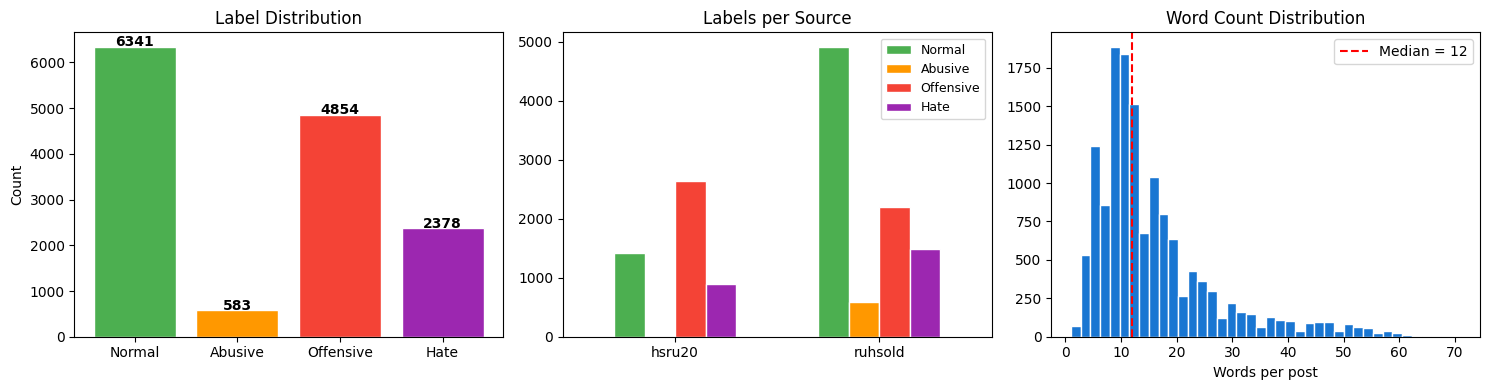

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label distribution
colors = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0']
counts = [( df_clean['unified_label'] == i).sum() for i in range(NUM_LABELS)]
axes[0].bar(LABEL_NAMES, counts, color=colors, edgecolor='white')
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=10)

# Source breakdown
src_lbl = df_clean.groupby(['source', 'unified_label']).size().unstack(fill_value=0)
src_lbl.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', width=0.6)
axes[1].set_title('Labels per Source')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(LABEL_NAMES, fontsize=9)

# Text length distribution
df_clean['word_count'] = df_clean['text'].str.split().str.len()
axes[2].hist(df_clean['word_count'], bins=40, color='#1976D2', edgecolor='white')
axes[2].axvline(df_clean['word_count'].median(), color='red', linestyle='--',
                label=f'Median = {df_clean["word_count"].median():.0f}')
axes[2].set_title('Word Count Distribution')
axes[2].set_xlabel('Words per post')
axes[2].legend()

plt.tight_layout()
plt.savefig('./eda.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Train / Val / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

df_train, df_temp = train_test_split(
    df_clean[['text', 'unified_label']],
    test_size=0.30, random_state=RANDOM_SEED,
    stratify=df_clean['unified_label'],
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=RANDOM_SEED,
    stratify=df_temp['unified_label'],
)

print('Split sizes (stratified 70 / 15 / 15):')
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    breakdown = {ID2LABEL[k]: v for k, v in split['unified_label'].value_counts().sort_index().items()}
    print(f'  {name:5s}: {len(split):5d}  {breakdown}')

Split sizes (stratified 70 / 15 / 15):
  Train:  9909  {'Normal': 4439, 'Abusive': 408, 'Offensive': 3398, 'Hate': 1664}
  Val  :  2123  {'Normal': 951, 'Abusive': 87, 'Offensive': 728, 'Hate': 357}
  Test :  2124  {'Normal': 951, 'Abusive': 88, 'Offensive': 728, 'Hate': 357}


## 9. Tokenisation

In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = 'FacebookAI/xlm-roberta-base'
MAX_LEN    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def df_to_hf(df):
    return Dataset.from_dict({
        'text':  df['text'].tolist(),
        'label': df['unified_label'].tolist(),
    })

def tokenise_batch(batch):
    return tokenizer(
        batch['text'],
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
    )

tok_train = df_to_hf(df_train).map(tokenise_batch, batched=True, desc='Train')
tok_val   = df_to_hf(df_val).map(tokenise_batch,   batched=True, desc='Val')
tok_test  = df_to_hf(df_test).map(tokenise_batch,  batched=True, desc='Test')

for ds in [tok_train, tok_val, tok_test]:
    ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print(f'✅ Tokenised  train={len(tok_train)}  val={len(tok_val)}  test={len(tok_test)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train:   0%|          | 0/9909 [00:00<?, ? examples/s]

Val:   0%|          | 0/2123 [00:00<?, ? examples/s]

Test:   0%|          | 0/2124 [00:00<?, ? examples/s]

✅ Tokenised  train=9909  val=2123  test=2124


## 10. Model

`classifier_dropout=0.30` applies only to the CLS head layer, matching the methodology exactly. The 12 transformer layers keep their default internal dropout of 0.1.

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    classifier_dropout=0.30,
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model         : {MODEL_NAME}')
print(f'Total params  : {total/1e6:.1f}M')
print(f'Trainable     : {trainable/1e6:.1f}M  (all 12 layers + head, fully fine-tuned)')
print(f'Num labels    : {NUM_LABELS}  → {LABEL_NAMES}')
print(f'Head dropout  : 0.30')

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model         : FacebookAI/xlm-roberta-base
Total params  : 278.0M
Trainable     : 278.0M  (all 12 layers + head, fully fine-tuned)
Num labels    : 4  → ['Normal', 'Abusive', 'Offensive', 'Hate']
Head dropout  : 0.30


## 11. Class Weights

In [ ]:
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from transformers import Trainer

class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_LABELS),
    y=df_train['unified_label'].values,
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(DEVICE)

print('Class weights (balanced):')
for name, w in zip(LABEL_NAMES, class_weights_np):
    print(f'  {name:12s}: {w:.4f}')

class WeightedTrainer(Trainer):
    """Injects class-weighted cross-entropy to counter label imbalance."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(weight=class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

Class weights (balanced):
  Normal      : 0.5581
  Abusive     : 6.0717
  Offensive   : 0.7290
  Hate        : 1.4887


## 12. Metrics

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy'    : round(accuracy_score(labels, preds), 4),
        'f1_macro'    : round(f1_score(labels, preds, average='macro',    zero_division=0), 4),
        'f1_weighted' : round(f1_score(labels, preds, average='weighted', zero_division=0), 4),
        'precision'   : round(precision_score(labels, preds, average='macro', zero_division=0), 4),
        'recall'      : round(recall_score(labels, preds, average='macro',    zero_division=0), 4),
    }

## 13. Training Configuration

In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback

BATCH_SIZE = 64
NUM_EPOCHS = 10
OUTPUT_DIR = './xlm-roberta-roman-urdu'

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.10,
    lr_scheduler_type           = 'linear',

    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,

    fp16                        = (DEVICE == 'cuda'),
    dataloader_num_workers      = 2,
    dataloader_pin_memory       = True,

    logging_dir                 = './logs',
    logging_steps               = 20,
    report_to                   = 'none',
    save_total_limit            = 2,
    seed                        = RANDOM_SEED,
)

trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = tok_train,
    eval_dataset    = tok_val,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

steps_per_epoch = len(tok_train) // BATCH_SIZE
print(f'Steps per epoch      : {steps_per_epoch}')
print(f'Warmup steps         : {int(steps_per_epoch * NUM_EPOCHS * 0.10)}')
print(f'Best model metric    : f1_macro')
print(f'Early stopping       : patience=2 epochs')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Steps per epoch      : 154
Warmup steps         : 154
Best model metric    : f1_macro
Early stopping       : patience=2 epochs


## 14. Train

In [ ]:
print('🚀 Starting training...')
result = trainer.train()

print('\n✅ Training complete!')
print(f'   Runtime      : {result.metrics["train_runtime"]:.0f}s')
print(f'   Train loss   : {result.metrics["train_loss"]:.4f}')
print(f'   Samples/sec  : {result.metrics["train_samples_per_second"]:.1f}')

🚀 Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,1.382046,1.342781,0.214800,0.191900,0.185000,0.340900,0.355000
2,1.268561,1.215470,0.370700,0.343000,0.375600,0.441800,0.456800
3,1.133498,1.103225,0.427200,0.403100,0.438100,0.474700,0.513000
4,1.066053,0.987187,0.515300,0.467200,0.517400,0.492300,0.588800
5,1.067782,0.942419,0.570900,0.521400,0.578500,0.512100,0.613200
6,0.939224,0.926998,0.579800,0.545700,0.594200,0.535900,0.629300
7,0.900465,0.934598,0.555300,0.526600,0.562500,0.544900,0.620300
8,0.905354,0.923985,0.576100,0.541700,0.578900,0.557900,0.629600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Training complete!
   Runtime      : 732s
   Train loss   : 1.1045
   Samples/sec  : 135.4


## 15. Training Curves

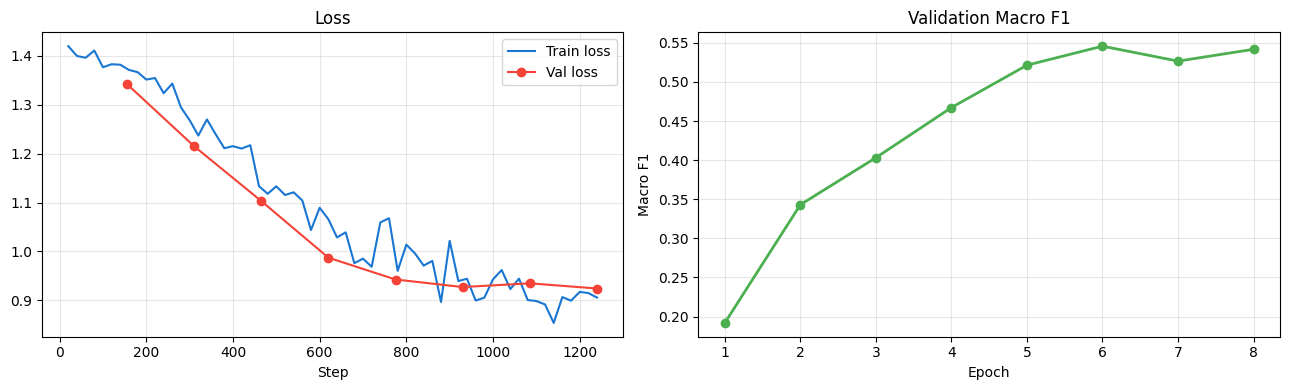

In [ ]:
history     = trainer.state.log_history
train_logs  = [l for l in history if 'loss'      in l and 'eval_loss' not in l]
eval_logs   = [l for l in history if 'eval_loss' in l]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if train_logs:
    axes[0].plot([l['step'] for l in train_logs],
                 [l['loss'] for l in train_logs],
                 label='Train loss', color='#1976D2')
if eval_logs:
    axes[0].plot([l['step'] for l in eval_logs],
                 [l['eval_loss'] for l in eval_logs],
                 label='Val loss', color='#F44336', marker='o')
axes[0].set_title('Loss')
axes[0].set_xlabel('Step')
axes[0].legend()
axes[0].grid(alpha=0.3)

if eval_logs and 'eval_f1_macro' in eval_logs[0]:
    axes[1].plot([l['epoch']        for l in eval_logs],
                 [l['eval_f1_macro'] for l in eval_logs],
                 color='#4CAF50', marker='o', linewidth=2)
    axes[1].set_title('Validation Macro F1')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro F1')
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 16. Evaluate on Test Set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

pred_out = trainer.predict(tok_test)
y_pred   = np.argmax(pred_out.predictions, axis=-1)
y_true   = pred_out.label_ids

print('📋 TEST SET — CLASSIFICATION REPORT')
print('─' * 60)
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0))

📋 TEST SET — CLASSIFICATION REPORT
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal       0.80      0.63      0.70       951
     Abusive       0.33      0.68      0.45        88
   Offensive       0.59      0.38      0.47       728
        Hate       0.37      0.74      0.49       357

    accuracy                           0.57      2124
   macro avg       0.52      0.61      0.53      2124
weighted avg       0.64      0.57      0.58      2124



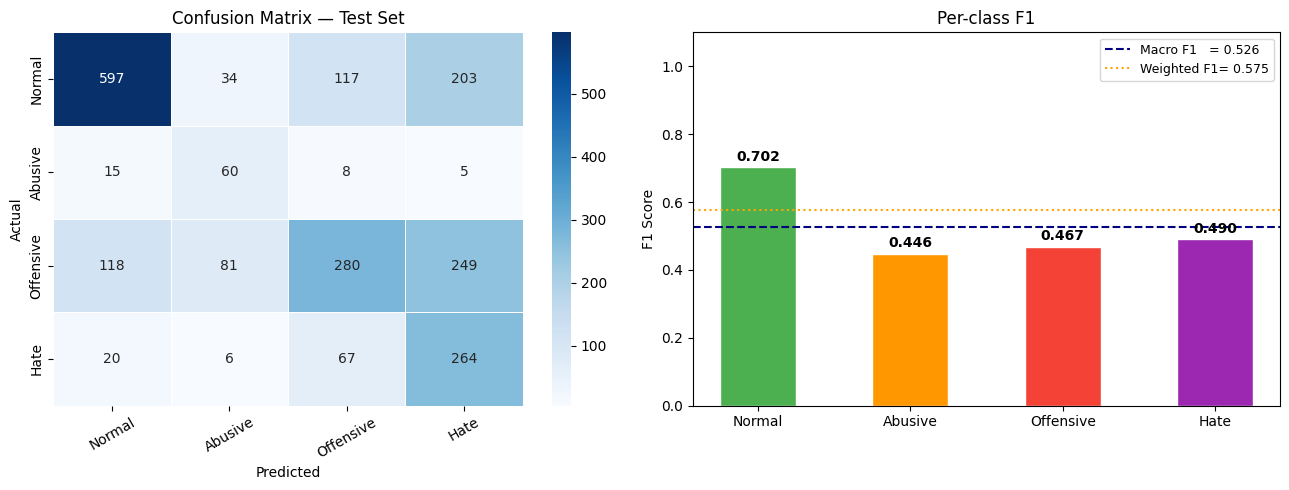

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Test Set')
axes[0].tick_params(axis='x', rotation=30)

# Per-class F1
f1_per = f1_score(y_true, y_pred, average=None, zero_division=0)
f1_mac = f1_score(y_true, y_pred, average='macro',    zero_division=0)
f1_wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
bars = axes[1].bar(LABEL_NAMES, f1_per, color=colors, edgecolor='white', width=0.5)
axes[1].axhline(f1_mac, color='navy',  linestyle='--', label=f'Macro F1   = {f1_mac:.3f}')
axes[1].axhline(f1_wt,  color='orange',linestyle=':',  label=f'Weighted F1= {f1_wt:.3f}')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-class F1')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, f1_per):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('./evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

## 17. Save Model

In [ ]:
SAVE_PATH = './xlm-roberta-roman-urdu-final'
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f'✅ Saved to {SAVE_PATH}')
for f in sorted(os.listdir(SAVE_PATH)):
    size = os.path.getsize(os.path.join(SAVE_PATH, f)) / 1e6
    print(f'  {f:45s} {size:.1f} MB')

!zip -r xlm-roberta-roman-urdu-final.zip {SAVE_PATH} -q
print('\n📦 Zipped — download from Colab file browser (left panel).')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved to ./xlm-roberta-roman-urdu-final
  config.json                                   0.0 MB
  model.safetensors                             1112.2 MB
  tokenizer.json                                16.8 MB
  tokenizer_config.json                         0.0 MB
  training_args.bin                             0.0 MB

📦 Zipped — download from Colab file browser (left panel).


## 18. Inference

In [ ]:
from transformers import pipeline

# The pipeline applies the same tokenizer — but NOT clean_text.
# Always preprocess input text before passing to the classifier.
classifier = pipeline(
    task='text-classification',
    model=SAVE_PATH, tokenizer=SAVE_PATH,
    device=0 if DEVICE == 'cuda' else -1,
    max_length=MAX_LEN, truncation=True,
)

test_sentences = [
    'Aap ka din acha guzre, Allah apko khush rakhe.',
    'In logo ko is mulk se nikal do, ye sab gande hain.',
    'yaar loooool ye tou bohat funny hai 😂😂😂',
    'Yeh qaum hamesha gaddari karti hai @user123 #HateSpeech',
    'bc kal match dekhna tha yaar miss hogya',
]

ICONS = {'Normal': '✅', 'Abusive': '🟠', 'Offensive': '🔴', 'Hate': '🚨'}

print(f'{"Text":<52} {"Label":<16} Score')
print('─' * 78)
for sent in test_sentences:
    cleaned = clean_text(sent)       # always preprocess first
    result  = classifier(cleaned)[0]
    label   = result['label']
    score   = result['score']
    icon    = ICONS.get(label, '')
    print(f'{sent[:50]:<52} {icon} {label:<14} {score:.3f}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Text                                                 Label            Score
──────────────────────────────────────────────────────────────────────────────
Aap ka din acha guzre, Allah apko khush rakhe.       ✅ Normal         0.721
In logo ko is mulk se nikal do, ye sab gande hain.   🔴 Offensive      0.447
yaar loooool ye tou bohat funny hai 😂😂😂              ✅ Normal         0.856
Yeh qaum hamesha gaddari karti hai @user123 #HateS   ✅ Normal         0.627
bc kal match dekhna tha yaar miss hogya              🟠 Abusive        0.895


---
## What was implemented

| Component | Detail |
|---|---|
| Datasets | RuHSold + HSRU-20 (both sheets merged) |
| Labels | Unified 4-class: Normal · Abusive · Offensive · Hate |
| Preprocessing 1 | Unicode NFC normalisation |
| Preprocessing 2 | Hashtag segmentation at camelCase and underscores |
| Preprocessing 3 | URL → `URL` placeholder token |
| Preprocessing 4 | @mention → `USER` placeholder token |
| Preprocessing 5 | Repeated character collapse (3+ → 2) |
| Preprocessing 6 | Emoji → text description via `emoji.demojize()` |
| Model | `FacebookAI/xlm-roberta-base` — all 12 layers trainable |
| Head dropout | 0.30 (on CLS token before dense layer) |
| Max length | 128 tokens, right-truncated |
| Loss | Weighted cross-entropy (class-balanced weights) |
| Best model | Selected by validation macro F1 |

**Not implemented (requires external resources):**
- Dewani et al. slang normalisation dictionary
- Third dataset (not named in methodology)